# <font color='#c0507d'>Disaster Response Simulation: Ambulance Allocation Project</font>

This notebook implements a Discrete Event Simulation (SimPy) for a mass-casualty disaster response following a coordinated UAV strike. It performs an exhaustive search optimization to determine the optimal allocation of ambulances across three impact sites, analyzing means and 95% Confidence Intervals (CI) across multiple replications.

### System Summary
* **Scenario:** A simultaneous UAV strike occurs at $t=0$ minutes across three urban sites (Small, Medium, Large).
* **Casualties:** All patients are generated immediately at $t=0$. The number of injured at each site is sampled from a Uniform Distribution.
* **Triage:** Patients are classified by severity (Severe, Moderate, Mild). Higher severity implies a shorter "Time to Death" (TTD) and higher priority for evacuation.
* **Resources:** There are `24` ambulances available, all starting at the central hospital.
* **Travel Times:** Distance means are fixed (15/S, 30/M, 45/L) and ambulance travel times were modeled using a Lognormal distribution for specific sites.
* **Process:** Ambulances utilize the "Scoop and Run" tactic.
* **Termination:** The simulation runs until all ambulances return to the hospital and either all injured patients across all three site have been evacuated, or/if they have succumbed to their injuries.

### Initial Assumptions
- There is only one hospital.
- Each ambulance can accommodate a single patient (1:1 ratio).
- Death is possible only before the ambulance collects them.
- Only a patient which has reached the hospital is defined as a success.
- At each explosion point (site) there is a point for concentrating the injured where all the injured are (from the same scene), so ambulances can find them immediately.
- We're assuming that the scoop and run tactic is used for the evacuation of patients (proven in the article to be more effective)
- The severity of injury of a patient will not change throughout the simulation run.
- All ambulances start their journey from the hospital and have to return to it by the end of the 24 hour cycle.
- After the travel time between the hospital and each scene is sampled, it will remain the same for each trip between the hospital and the same scene.

 #### *<font color='blue'>Research question</font>*
"How to optimally allocate 24 ambulances across 3 disaster sites to maximize the survival rate?"

### Objectives
We aim to answer the research question above, and will estimate:
- Success/Survival Rate: The percentage of casualties successfully transported to the hospital alive.
- Mortality: The count of patients dead on scene.
- Optimal Allocation: The specific assignment $(n_{Small}, n_{Medium}, n_{Large})$ that yields the statistically highest mean survival rate.

In [ ]:
# if necessary
!pip install simpy

In [1]:
# Python package imports
import simpy
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import LinearSegmentedColormap

---

## Parameters

- **Ambulance:** fixed number of 24 ambulances available.
- **Simulation duration:** a single simulation runs for a max of 24 hours (14,400 minutes)..
- **Site:**
    - `dist`: Fixed travel time in minutes (one-way)
    - `count_range`: (min, max) for Uniform Distribution of injured patients
    - `sev_prob`: The probability for each severity in the site [Severe, Moderate, Mild]
- **Severity:**
    - `priority`: Lower number = Higher priority in SimPy PriorityStore
    - `ttd_mean`: Time To Death Mean for Normal Distribution
    - `ttd_std`: Time To Death Standard Deviation for Normal Distribution

#### Initialization
 At $ t=0$, patients are generated at 3 sites with assigned severities and "Time to Death" (TTD) values sampled from Truncated Normal distributions (to account for the non-negative nature of time).

In [ ]:
# Simulation Constants
NUM_AMBULANCES = 24
SAMPLE_DT = 1  # Sample stats every minute
SIM_DURATION = 24 * 60  # A single simulation runs for a max of 24 hours (minutes)
RANDOM_SEED = 42

# Site Parameters
SITES = {
    'Small':  {'dist': 15, 'std': 4,  'count_range': (5, 10),   'sev_prob': [0.7, 0.2, 0.1]},
    'Medium': {'dist': 30, 'std': 8,  'count_range': (20, 35),  'sev_prob': [0.3, 0.5, 0.2]},
    'Large':  {'dist': 45, 'std': 12, 'count_range': (45, 60),  'sev_prob': [0.1, 0.2, 0.7]}
}

# Patient Severity Parameters
SEVERITY = {
    'Severe':   {'priority': 1, 'ttd_mean': 60,  'ttd_std': 15},
    'Moderate': {'priority': 2, 'ttd_mean': 120, 'ttd_std': 30},
    'Mild':     {'priority': 3, 'ttd_mean': 300, 'ttd_std': 60}
}

---
### Helper functions

#### Time To Death (TTD): Truncated Normal Distribution
Law, A. M. (2014). _Simulation Modeling and Analysis (5th ed. Chapter 6)_. McGraw-Hill Education.

For this simulation, we had to decide how to model 'Time to Death' without having access to real-world mortality logs from a UAV strike. While time-to-event models often utilize Weibull distributions, these models require specific 'shape' parameters that are impossible to know without historical data. According to Law (2014) when no data are available, using complex distributions (like Weibull/Gamma) without data to fit them is dangerous because the results would be based on a guess. Therefore, the Truncated Normal distribution was selected for this simulation.


#### Ambulance Travel Time: Lognormal Distribution
Budge, A. S., Ingolfsson, A., & Zerom, D. (2010). _"Empirical analysis of ambulance travel times: The case of Calgary Emergency Medical Services."_ Management Science.

This paper proves that ambulance travel times are best modeled by a Lognormal distribution.

In [ ]:
def get_normal_params(mean: float, std: float, min_val: float = 1.0) -> float:
    """
    Samples from a normal distribution, ensuring the result value >= min_val
    and forces a non-negative result for times like TTD (Time To Death).
    """
    val = float(abs(np.random.normal(mean, std)))
    return max(min_val, val)

def get_uniform_params(min_val: int, max_val:int) -> int:
    """
    Samples an integer from a Uniform distribution [min, max].
    Used for patient counts.
    """
    return np.random.randint(min_val, max_val + 1)

def get_lognormal_params(mean: float, std: float) -> tuple[float, float]:
    """
    Converts the arithmetic Mean and Std Dev (e.g., 15 mins +/- 4)
    into the mu and sigma required for the Lognormal formula.
    """
    var = std ** 2
    mu = np.log(mean**2 / np.sqrt(var + mean**2))
    sigma = np.sqrt(np.log(var / mean**2 + 1))
    return mu, sigma

---

## Processes
#### Patient Initialization
This simulation initializes the entire mass-casualty scenario at $t=0$ (therefor arrival time of patients is fixed).
1. The system samples the number of injured for each site from a Uniform Distribution.
2. Each patient is assigned a Severity level of injury based on fixed probabilities.
3. A specific Time-to-Death (TTD) is generated for each patient using a Truncated Normal Distribution.
4. Patients are placed in a Priority Queue at their respective site, strictly ordered by severity (severe $\to$ moderate $\to$ mild), waiting for evacuation.

#### Ambulance
Each ambulance operates as an independent process:
1. **Deployment:** Samples a travel time from a Lognormal Distribution (representing traffic/distance in minutes) and travels from the hospital to its assigned site.
2. **Loading:** Picks the highest priority patient.
3. **Evacuation:** If `Current Time < Patient TTD`: The patient is Alive. The ambulance performs a "Scoop and Run" and records a "Save".
   Else, if `Current Time > Patient TTD`: The patient is declared "Deceased". The ambulance records the death, does not transport the body and immediately attempts to sieze the next patient (no transport).
4. **Discharge:** Travels back from site to the hospital (sampled time + loading time), records a "Success" and discharges the patient.
5. If the system queue isn't empty, loop back to step 1.

#### Arrivals
The simulation runs until the system is empty: meaning all patients have been processed (either successfully evacuated or deceased), and all ambulances have returned to the hospital.

In [ ]:
class Patient:
    def __init__(self, p_id: int, severity: str, site_name: str, ttd: float):
        """
        Represents a single injured patient entity in the disaster simulation.

        A Patient is created at t=0 at a specific site and assigned a severity level and a "Time To Death" (TTD).
        The patient waits in a priority queue until collected by an ambulance or until their TTD passes.

        Attributes
        ----------
        p_id: Unique identifier for the patient.
        site: Name of the site where the patient is located (Small, Medium, Large).
        severity: The triage category (Severe, Moderate, Mild).
        ttd: Time To Death. If simulation time exceeds this, the patient dies.
        arrival_time: Time when the patient "arrived" the scene (t=0 for this scenario).
        status: Tracks current state ('Waiting', 'Deceased', 'Saved').
        collect_time: The simulation time when the patient successfully arrived at the hospital ('Saved').
        """
        self.p_id = p_id
        self.severity = severity
        self.site_name = site_name
        self.ttd = ttd # time to death
        self.arrival_time = 0
        self.status = 'Waiting' # Waiting, Deceased, Saved
        self.collect_time = None

In [ ]:
def ambulance(env, amb_id, site_name, site_queue, state, t_mean, t_std,):
    """
    SimPy process for a single ambulance.
    """
    state['active_ambulances'] += 1

    # Calculate Log-Space parameters for this route
    mu, sigma = get_lognormal_params(t_mean, t_std)

    while True:
        # 1. Travel Out (Hospital -> Site)
        # Sample Lognormal. Ensuring min travel time is at least 5 mins.
        travel_time = max(5, np.random.lognormal(mu, sigma))
        t_depart = env.now
        yield env.timeout(travel_time)
        state['busy_time_by_site'][site_name] += (env.now - t_depart)

        # 2. Pick up logic (Loop until we find a live patient or queue empty)
        patient_found = False

        while not patient_found:
            # A. Check if the site is empty
            if len(site_queue.items) == 0:
                state['active_ambulances'] -= 1
                # If this was the last ambulance and queues are empty, finish simulation (trigger done)
                if state['active_ambulances'] == 0 and not state['done'].triggered:
                    state['done'].succeed(env.now)
                return  # Ambulance retires

            # B. Get highest priority patient
            prio, pid, patient = yield site_queue.get() # (priority_int, unique_id, patient_obj)

            # C. Check survival
            if env.now < patient['ttd']: # Patient is ALIVE -> Transport
                wait_t = env.now - patient.get('arrival_time', 0)
                state['wait_times_all'].append(wait_t)
                state['wait_times_by_site'][site_name].append(wait_t)
                state['wait_times_by_sev'][patient['severity']].append(wait_t)
                patient_found = True
                patient['status'] = 'Saved'
            else:
                # Patient is DEAD -> Record and check next immediately
                state['deceased'] += 1
                state['in_system'] -= 1
                # we don't yield a timeout here (dead check is instant)

                # Update patient object status (optional, for debugging)
                patient['status'] = 'Deceased'

        # 3. Travel Site -> Hospital (Fixed time)
        yield env.timeout(travel_time + 2) # +2 minutes loading/unloading overhead

        # 4. Record Successful pickup
        state['saved'] += 1
        state['in_system'] -= 1

        # If we saved the last patient, check if system is now empty
        if state['in_system'] == 0 and not state['done'].triggered:
            state["end_time"] = env.now
            state['done'].succeed(env.now)

In [ ]:
def sampler(env, state, dt=SAMPLE_DT):
    """
    Background process: Samples system stats every 'dt' minutes.
    """
    while not state['done'].triggered:
        state['ts_t'].append(env.now)
        state['ts_saved'].append(state['saved'])
        state['ts_deceased'].append(state['deceased'])
        state['ts_in_system'].append(state['in_system'])
        yield env.timeout(dt)

---

### Run a single replication

In [ ]:
def run_one_rep(allocation, seed):
    """
    Sets up and runs one replication of the simulation.
    """
    np.random.seed(seed)

    env = simpy.Environment()

    # State Dictionary
    state = {
        'done': env.event(),   # Event to trigger when the current simulation is over
        'in_system': 0,        # Total patients currently waiting or being transported
        'active_ambulances': 0,

        # Counters
        'total_patients': 0,
        'saved': 0,
        'deceased': 0,

        # Waiting-time tracking
        'wait_times_all': [],
        'wait_times_by_site': {k: [] for k in SITES.keys()},
        'wait_times_by_sev': {k: [] for k in SEVERITY.keys()},

        # Utilization tracking (busy time per site)
        'busy_time_by_site': {k: 0.0 for k in SITES.keys()},
        'alloc': None,          # store allocation for utilization denominator
        'end_time': None,       # time when system finished

        # Time series
        'ts_t': [],
        'ts_saved': [],
        'ts_deceased': [],
        'ts_in_system': []
    }

    # Initialize Sites
    site_queues = {}
    pid = 0 # Patient ID counter

    for site, params in SITES.items():
        site_queues[site] = simpy.PriorityStore(env)

        # Generate patients (queues)
        min_c, max_c = params['count_range']
        count = get_uniform_params(min_c, max_c) # sample Count (Uniform Distribution)

        state['total_patients'] += count
        state['in_system'] += count

        for _ in range(count):
            # Sample Severity
            sev = np.random.choice(['Severe', 'Moderate', 'Mild'], p=params['sev_prob'])

            # Sample Time To Death (Normal Distribution)
            ttd_params = SEVERITY[sev]
            ttd = get_normal_params(ttd_params['ttd_mean'], ttd_params['ttd_std'], min_val=5)

            # Create Patient
            p_info = {'id': pid, 'severity': sev, 'site': site, 'ttd': ttd, 'arrival_time': 0}

            # Add to queue: (Priority, UniqueID, Object)
            site_queues[site].put((SEVERITY[sev]['priority'], pid, p_info))
            pid += 1


    # Start Ambulances Processes
    amb_id_counter = 0
    for site, num_amb in allocation.items():
        # Get the travel time for this site
        dist_time = SITES[site]['dist']
        t_std = SITES[site]['std']

        for _ in range(num_amb):
            env.process(ambulance(env, amb_id_counter, site, site_queues[site], state, dist_time, t_std))
            amb_id_counter += 1


    # Start Sampler
    env.process(sampler(env, state))

    # Run Simulation
    env.run(until=state['done'])
    state['end_time'] = env.now

    # Summarize Results
    success_rate = (state['saved'] / state['total_patients']) * 100 if state['total_patients'] > 0 else 0

    # Time series summary
    ts = pd.DataFrame({
        't': state['ts_t'],
        'saved': state['ts_saved'],
        'dead': state['ts_deceased'],
        'in_system': state['ts_in_system']
    })

    # Utilization by site
    util_by_site = {}
    for site in SITES.keys():
        num_amb = allocation[site]
        T = state['end_time'] if state['end_time'] and state['end_time'] > 0 else np.nan
        util_by_site[site] = (state['busy_time_by_site'][site] / (num_amb * T)) if (num_amb > 0 and T == T) else np.nan

    # Waiting means (site + severity)
    def mean_or_nan(x):
        return float(np.mean(x)) if len(x) else np.nan

    summary = {
        'Total Patients': state['total_patients'],
        'Saved': state['saved'],
        'Dead': state['deceased'],
        'SuccessRate': success_rate,
        'EndTime': env.now,

        'MeanWait_All': mean_or_nan(state['wait_times_all']),
        'MeanWait_Small': mean_or_nan(state['wait_times_by_site']['Small']),
        'MeanWait_Medium': mean_or_nan(state['wait_times_by_site']['Medium']),
        'MeanWait_Large': mean_or_nan(state['wait_times_by_site']['Large']),

        'MeanWait_Severe': mean_or_nan(state['wait_times_by_sev']['Severe']),
        'MeanWait_Moderate': mean_or_nan(state['wait_times_by_sev']['Moderate']),
        'MeanWait_Mild': mean_or_nan(state['wait_times_by_sev']['Mild']),

        'Util_Small': util_by_site['Small'], #Ambulances Utilization
        'Util_Medium': util_by_site['Medium'],
        'Util_Large': util_by_site['Large'],

        'MaxWait_All': float(np.max(state["wait_times_all"])) if len(state["wait_times_all"]) else np.nan,
        'P95Wait_All': float(np.percentile(state["wait_times_all"], 95)) if len(state["wait_times_all"]) else np.nan
    }

    return summary, ts

---

### Multiple replications
We compute the sample mean and a 95% CI half‑width using:
$ \bar{X} \pm 1.96 \sqrt{S^2 / n} $

In [ ]:
import sys # Import sys to force output flushing

def run_experiment_exhaustive():
    """
     Iterates through ALL valid combinations of 24 ambulances.
     Runs N replications per combination.
     Calculates Mean and 95% Confidence Interval.
     """

    # 1. Generate Scenarios (Allocations)
    scenarios = []
    for s in range(1, 23): # partitions of 24 ambulances
        for m in range(1, 23 - s):
            l = 24 - s - m
            if l >= 1:
                scenarios.append({'Small': s, 'Medium': m, 'Large': l})

    print(f"Total scenarios to test: {len(scenarios)}")
    print("Starting! Running simulations (this may take a while).")

    final_results = []
    NUM_REPS = 30

    print("Processing ", end="")

    for idx, alloc in enumerate(scenarios):

        rep_success = []
        rep_summaries = []

        # Run N replications for this scenario (once)
        for r in range(NUM_REPS):
            summary, _ = run_one_rep(alloc, seed=RANDOM_SEED + r + (idx*100)) # unique seed per replication
            rep_success.append(summary['SuccessRate'])
            rep_summaries.append(summary)

        ##### Single run Statistics: Mean & 95% CI Half-Width
        n = len(rep_success)
        mean_val = np.mean(rep_success)
        std_val = np.std(rep_success, ddof=1) # Sample standard deviation
        ci_half = 1.96 * (std_val / np.sqrt(n))

        #### New DataFrame for extra metrics we found necessary
        df_rep = pd.DataFrame(rep_summaries)
        mean_success = df_rep["SuccessRate"].mean()
        std_success = df_rep["SuccessRate"].std(ddof=1)
        ci_half_df = 1.96 * (std_success / np.sqrt(len(df_rep)))

        final_results.append({
            "Small": alloc["Small"],
            "Medium": alloc["Medium"],
            "Large": alloc["Large"],
            "Mean_Success": mean_val,
            "CI_HalfWidth": ci_half,

            "MeanWait_All": df_rep["MeanWait_All"].mean(),
            "MeanWait_Small": df_rep["MeanWait_Small"].mean(),
            "MeanWait_Medium": df_rep["MeanWait_Medium"].mean(),
            "MeanWait_Large": df_rep["MeanWait_Large"].mean(),

            "Util_Small": df_rep["Util_Small"].mean(),
            "Util_Medium": df_rep["Util_Medium"].mean(),
            "Util_Large": df_rep["Util_Large"].mean(),

            "MaxWait_All": df_rep["MaxWait_All"].mean(),
            "P95Wait_All": df_rep["P95Wait_All"].mean()
        })

        # Add a dot every 5 iterations
        if idx % 5 == 0:
            print(".", end="", flush=True)

    print(" Done!")
    return pd.DataFrame(final_results)

---

### Output Analysis
This section performs output analysis on the simulation results.

In [ ]:
if __name__ == "__main__":
    # Run the full experiment
    df_results = run_experiment_exhaustive()

    # Identify Best Allocation
    best_idx = df_results['Mean_Success'].idxmax()
    best_row = df_results.loc[best_idx]

    print("\n" + "="*25)
    print("OPTIMAL ALLOCATION FOUND!")
    print("="*25)
    print(f"Small:  {int(best_row['Small'])}")
    print(f"Medium: {int(best_row['Medium'])}")
    print(f"Large:  {int(best_row['Large'])}")
    print(f"Success Rate: {best_row['Mean_Success']:.2f}% ± {best_row['CI_HalfWidth']:.2f}")


    ##################################
    # Show Top & Worst 10 Data Tables
    ##################################
    print("\nTop 10 Allocations:")
    try:
        display(df_results.sort_values('Mean_Success', ascending=False).head(10))
    except NameError:
        print(df_results.sort_values('Mean_Success', ascending=False).head(10))

    # Show Worst 10 Data Table
    print("\nWorst 10 Allocations:")
    try:
        display(df_results.sort_values('Mean_Success', ascending=True).head(10))
    except NameError:
        print(df_results.sort_values('Mean_Success', ascending=True).head(10))

Total scenarios to test: 231
Starting! Running simulations (this may take a while).
Processing ............................................... Done!

OPTIMAL ALLOCATION FOUND!
Small:  2
Medium: 7
Large:  15
Success Rate: 84.06% ± 1.74

Top 10 Allocations:


,Small,Medium,Large,Mean_Success,CI_HalfWidth,MeanWait_All,MeanWait_Small,MeanWait_Medium,MeanWait_Large,Util_Small,Util_Medium,Util_Large,MaxWait_All,P95Wait_All
27,2,7,15,84.057014,1.739594,120.067619,46.406212,93.222205,141.025029,0.176490,0.362271,0.494187,279.838988,257.611467
6,1,7,16,83.810295,1.799302,118.297270,64.038872,89.384159,134.483070,0.234254,0.365912,0.487752,268.820567,245.982501
28,2,8,14,83.605440,1.926468,118.860578,44.843761,84.721856,144.674779,0.171318,0.334786,0.489205,287.133171,263.818675
48,3,8,13,83.473256,1.621257,124.493501,33.198076,84.725125,156.372665,0.127529,0.312603,0.490005,308.078839,283.010237
46,3,6,15,83.411067,1.243167,119.856433,36.304915,99.648959,139.434677,0.151442,0.383449,0.486705,278.617300,254.990551
30,2,10,12,83.230937,1.965876,120.696020,44.696189,73.895823,157.473079,0.161317,0.281119,0.488182,311.852577,284.033760
47,3,7,14,83.152884,1.955011,121.323434,35.857400,89.887234,147.467895,0.145421,0.340548,0.491122,293.692933,268.687237
9,1,10,13,83.131056,1.948963,121.738052,68.052217,72.727786,153.268229,0.228311,0.289684,0.489252,301.508557,278.857825
5,1,6,17,82.946101,1.718182,119.409455,61.131008,98.901694,131.259236,0.231067,0.405947,0.488195,259.760139,243.774233
7,1,8,15,82.869185,1.646824,121.925203,64.113421,85.140180,143.802553,0.228167,0.338678,0.490587,285.320719,263.914490



Worst 10 Allocations:


,Small,Medium,Large,Mean_Success,CI_HalfWidth,MeanWait_All,MeanWait_Small,MeanWait_Medium,MeanWait_Large,Util_Small,Util_Medium,Util_Large,MaxWait_All,P95Wait_All
230,21,1,2,25.295873,0.960399,127.448633,11.291109,160.829664,200.207883,0.045494,0.412078,0.519275,377.279017,342.360667
228,20,1,3,29.202350,1.129932,137.248269,11.212702,164.784364,198.040302,0.046326,0.426506,0.507699,378.774416,349.008959
229,20,2,2,29.817164,0.817353,126.334413,11.359281,147.081511,204.798674,0.045665,0.374359,0.521637,383.228949,336.321830
227,19,3,2,31.882956,1.094932,122.695000,11.229344,125.043463,204.314928,0.044421,0.329866,0.514476,388.970836,326.316868
225,19,1,4,33.501685,1.298772,148.159221,11.405119,173.436325,194.010488,0.045726,0.450900,0.497066,377.994381,349.827499
226,19,2,3,34.666383,1.546649,136.780801,11.369783,141.943742,203.070415,0.046694,0.378944,0.499095,388.540484,348.112407
224,18,4,2,35.598800,1.142394,116.634497,11.732698,113.049207,204.695626,0.046374,0.309376,0.521344,381.314479,319.727464
223,18,3,3,36.926545,1.126093,132.601395,11.102463,126.073390,201.985830,0.046126,0.339112,0.510322,382.398509,344.353659
220,17,5,2,38.456234,1.173789,111.006730,11.621048,105.598755,206.872836,0.047451,0.293477,0.520941,382.598981,312.181567
222,18,2,4,38.922243,1.654499,142.014241,11.639177,143.064306,194.536861,0.048817,0.389808,0.500602,380.235160,343.833891


---

### Plots

#### Comparison of Survival Rates: Top 5 vs. Worst 5 Allocation Strategies
This bar chart compares the mean survival rates of the five most effective and five least effective ambulance allocation configurations. The x-axis represents the specific allocation tuple $(n_{Small}, n_{Medium}, n_{Large})$, and the error bars indicate the 95% Confidence Interval across 30 replications.

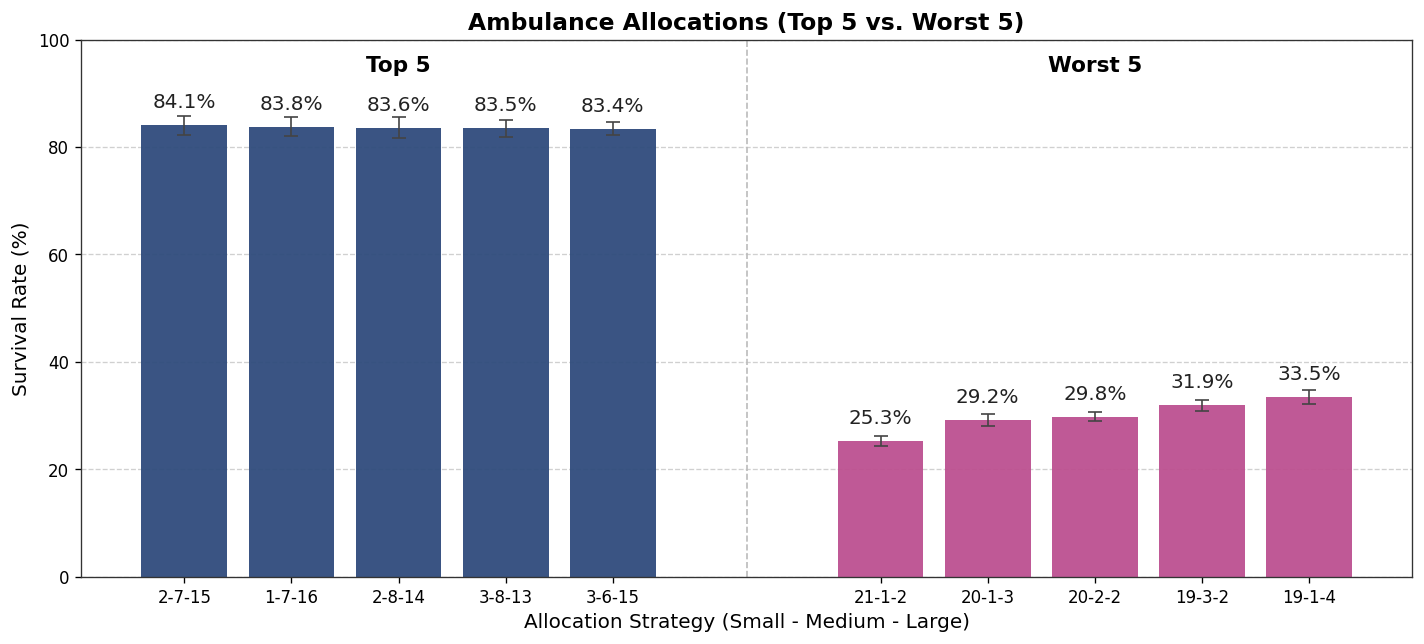

In [ ]:
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 120,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "grid.color": "#d0d0d0",
    "grid.linestyle": "--",
    "grid.linewidth": 0.8,
})

# PREPARE DATA
df_sorted = df_results.sort_values("Mean_Success", ascending=False)
top_5 = df_sorted.head(5)
worst_5 = df_sorted.tail(5).sort_values("Mean_Success", ascending=True)

def create_labels(df):
    return [f"{int(r.Small)}-{int(r.Medium)}-{int(r.Large)}" for _, r in df.iterrows()]

labels_top = create_labels(top_5)
labels_worst = create_labels(worst_5)

# Build combined x positions with a gap between groups
gap = 1.5  # controls whitespace between Best and Worst groups
x_top = np.arange(len(top_5))
x_worst = np.arange(len(worst_5)) + len(top_5) + gap
x_all = np.concatenate([x_top, x_worst])

labels_all = labels_top + labels_worst

means_all = np.concatenate([top_5["Mean_Success"].to_numpy(), worst_5["Mean_Success"].to_numpy()])
ci_all = np.concatenate([top_5["CI_HalfWidth"].to_numpy(), worst_5["CI_HalfWidth"].to_numpy()])

ERR_COLOR = "#444444"
WORST = "#bc5090"
BEST  = "#2f4b7c"

colors_all = [BEST]*len(top_5) + [WORST]*len(worst_5)

# --- PLOT ---
fig, ax = plt.subplots(figsize=(12, 5.5))

bars = ax.bar(
    x_all,
    means_all,
    yerr=ci_all,
    capsize=4,
    color=colors_all,
    edgecolor="none",
    alpha=0.95,
    error_kw={"ecolor": ERR_COLOR, "elinewidth": 1.0, "capthick": 1.0},
)

# Value labels above bars
ymax = 100
ax.set_ylim(0, ymax)
for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.025 * ymax,   # 2.5% of axis height for spacing
        f"{h:.1f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        color="#222222",
    )

# X ticks/labels
ax.set_xticks(x_all)
ax.set_xticklabels(labels_all)

# Separator line between groups
sep_x = (x_top[-1] + x_worst[0]) / 2
ax.axvline(sep_x, linestyle="--", linewidth=1.0, color="#bbbbbb")

# Group annotations
ax.text(x_top.mean(), 97, "Top 5", ha="center", va="top", fontsize=13, fontweight="bold")
ax.text(x_worst.mean(), 97, "Worst 5", ha="center", va="top", fontsize=13, fontweight="bold")

ax.set_xlabel("Allocation Strategy (Small - Medium - Large)")
ax.set_ylabel("Survival Rate (%)")
ax.set_title("Ambulance Allocations (Top 5 vs. Worst 5)")

ax.grid(axis="y")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

The optimal strategies consistently allocate a major portion of resources (approx. 13-16 ambulances) to the 'Large' site. Conversely, the worst performing strategies allocate minimal resources (2-3 ambulances) to the 'Large' site, causing a drastic drop in survival rates (from ~84% to ~25%). This confirms that resource allocation must be proportional to the site's casualty load and distance.

---
#### Global Performance Landscape: Ranked Efficiency of All Allocation Strategies
This chart visualizes the performance spectrum of every valid ambulance allocation combination tested in the simulation. The strategies are sorted by Mean Success Rate (survival percentage) from lowest to highest along the x-axis. The solid blue line represents the performance trajectory. The red and green markers explicitly identify the worst and best configurations (formatted as $N_{Small}-N_{Medium}-N_{Large}$), while the dashed gray line indicates the overall average survival rate across all possible scenarios.

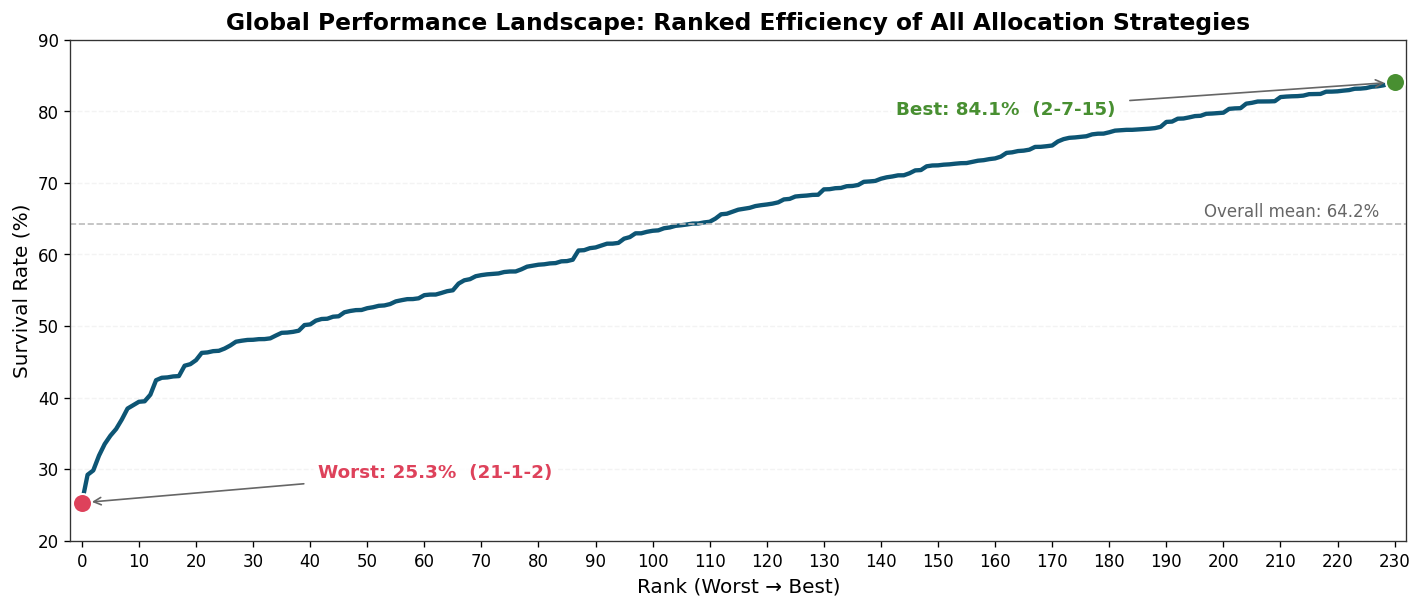

In [ ]:
WORST = "#de425b"
BEST  = "#488f31"
LINE  = "#004c6d"

# Sort WORST -> BEST
df_sorted = df_results.sort_values("Mean_Success", ascending=True).reset_index(drop=True)

def alloc_str(r):
    return f"{int(r.Small)}-{int(r.Medium)}-{int(r.Large)}"

alloc_labels = [alloc_str(r) for _, r in df_sorted.iterrows()]

x = np.arange(len(df_sorted))
y = df_sorted["Mean_Success"].to_numpy()

worst_idx = 0
best_idx = len(df_sorted) - 1

# Dynamic padding so labels have room
yr = y.max() - y.min()
pad_y = max(4, 0.08 * yr)

fig, ax = plt.subplots(figsize=(12, 5.2))

# Single-color line (no color changes) + no dots
ax.plot(x, y, color=LINE, linewidth=2.6, alpha=0.95)

# Only two highlighted points
ax.scatter([worst_idx], [y[worst_idx]], s=130, color=WORST, edgecolor="white", linewidth=1.2, zorder=5)
ax.scatter([best_idx],  [y[best_idx]],  s=130, color=BEST,  edgecolor="white", linewidth=1.2, zorder=5)

ax.set_xlim(x.min() - 2, x.max() + 2)
ax.set_ylim(y.min() - pad_y, y.max() + pad_y)

ax.set_xlabel("Rank (Worst → Best)")
ax.set_ylabel("Survival Rate (%)")
ax.set_title("Global Performance Landscape: Ranked Efficiency of All Allocation Strategies")
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
ax.set_xticks([])

# Labels in white boxes (prevents overlap with the line)
bbox_kw = dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.9)
arrow_kw = dict(arrowstyle="->", color="#666666", lw=1.0, shrinkA=6, shrinkB=6)

# Place worst label ABOVE the curve area
ax.annotate(
    f"Worst: {y[worst_idx]:.1f}%  ({alloc_labels[worst_idx]})",
    xy=(worst_idx, y[worst_idx]),
    xytext=(x.max()*0.18, y.min() + pad_y*0.75),
    textcoords="data",
    bbox=bbox_kw,
    arrowprops=arrow_kw,
    fontsize=11,
    color=WORST,
    fontweight="bold",
)

# Place best label BELOW the curve area (but still inside axes)
ax.annotate(
    f"Best: {y[best_idx]:.1f}%  ({alloc_labels[best_idx]})",
    xy=(best_idx, y[best_idx]),
    xytext=(x.max()*0.62, y.max() - pad_y*0.95),
    textcoords="data",
    bbox=bbox_kw,
    arrowprops=arrow_kw,
    fontsize=11,
    color=BEST,
    fontweight="bold",
)

# X axis: show rank numbers every 10
n = len(x)
step = 10
xt = np.arange(0, n, step)
if xt[-1] != n - 1:
    xt = np.append(xt, n - 1)   # show last rank too

ax.set_xticks(xt)
ax.set_xticklabels([str(v) for v in xt])

# Y axis: show % ticks every 10
ymin = int(np.floor(ax.get_ylim()[0] / 10) * 10)
ymax = int(np.ceil(ax.get_ylim()[1] / 10) * 10)
ax.set_yticks(np.arange(ymin, ymax + 1, 10))

# --- Overall mean line + numeric label ---
mean_val = float(np.mean(y))
ax.axhline(mean_val, linestyle="--", linewidth=1.0, color="#bbbbbb")
ax.text(
    0.98, mean_val + 0.5,
    f"Overall mean: {mean_val:.1f}%",
    transform=ax.get_yaxis_transform(),  # x in axes coords, y in data coords
    ha="right",
    va="bottom",
    fontsize=10,
    color="#666666"
)

plt.tight_layout()
plt.show()


The graph demonstrates the high sensitivity of the system to decision-making. There is a drastic gap between the worst strategy (marked in red) and the optimal strategy (marked in green), highlighting that incorrect resource distribution can lead to a massive loss of life. Furthermore, the fact that the "Best" point sits significantly higher than the "Overall mean" confirms that a naive or random allocation is insufficient; optimization is essential to push the system to its maximum life-saving potential.

---
#### Efficiency Landscape: Impact of Resource Balance Between Small and Large Sites
This heatmap projects the system's mean survival rate onto a 2-dimensional plane defined by the allocation of ambulances to the 'Small' (x-axis) and 'Large' (y-axis) sites. The allocation for the 'Medium' site is implicitly determined by the remaining resources ($N_{Medium} = 24 - N_{Small} - N_{Large}$). The color gradient transitions from red (poor performance) to green (optimal performance), allowing for quick identification of effective resource distributions.

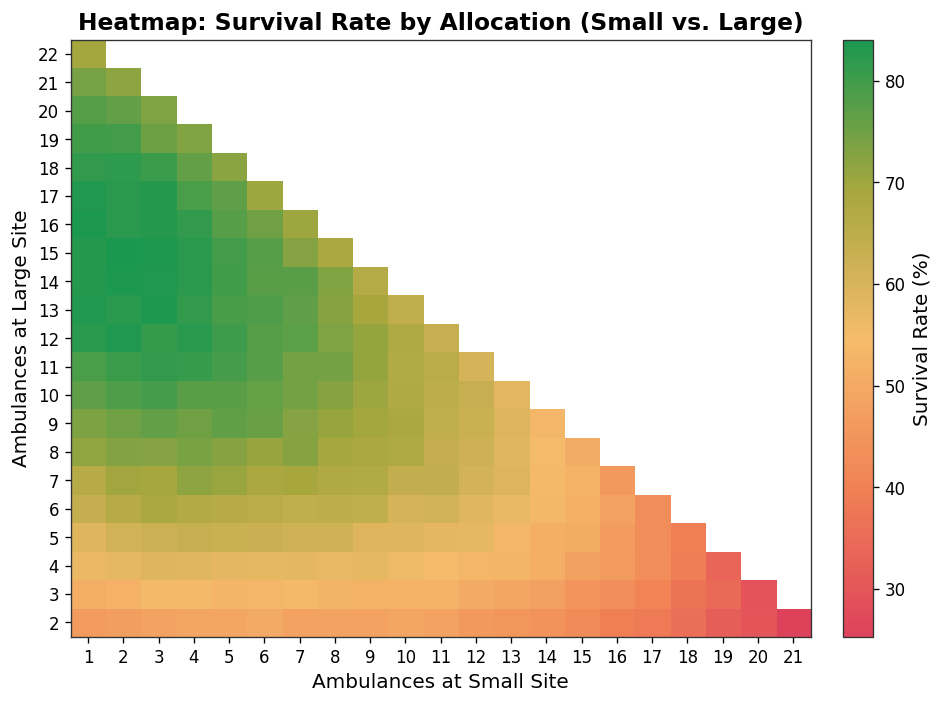

In [ ]:
# Color scale: Red -> Yellow -> Green (worst to best)
cmap_rg = LinearSegmentedColormap.from_list("rg", ["#de425b","#f18255", "#f5bc6b", "#a6a73e", "#1a9850"], N=256)

heatmap_sl = df_results.pivot_table(index="Large", columns="Small", values="Mean_Success")
heatmap_sl = heatmap_sl.sort_index().sort_index(axis=1)

x_vals = heatmap_sl.columns.to_numpy()
y_vals = heatmap_sl.index.to_numpy()
Z = heatmap_sl.to_numpy()

fig, ax = plt.subplots(figsize=(8, 6))
extent = [x_vals.min()-0.5, x_vals.max()+0.5, y_vals.min()-0.5, y_vals.max()+0.5]

im = ax.imshow(
    Z,
    origin="lower",
    aspect="auto",
    cmap=cmap_rg,
    extent=extent,
    interpolation="nearest",
    zorder=2
)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Survival Rate (%)")

ax.set_xlabel("Ambulances at Small Site")
ax.set_ylabel("Ambulances at Large Site")
ax.set_title("Heatmap: Survival Rate by Allocation (Small vs. Large)")

ax.set_xticks(x_vals)
ax.set_yticks(y_vals)

ax.grid(False)  # important: remove overlay lines
plt.tight_layout()
plt.show()


The visualization reveals a clear "Green Zone" in the upper-left region, corresponding to a high allocation for the 'Large' site (approx. 13-16 ambulances) and a minimal allocation for the 'Small' site (1-3 ambulances). This visually confirms that the system is highly sensitive to under-resourcing the Large site; moving downwards on the Y-axis (reducing 'Large' resources) causes a rapid shift to orange and red, indicating a sharp decline in survival rates regardless of how many resources are given to the smaller sites.

#### Marginal Impact Analysis: System Mortality vs. Site Resource Allocation
This heatmap isolates the impact of assigning a specific number of ambulances to a single site on the global mortality rate. Each cell represents the average mortality across all valid simulation scenarios where the specific site received the number of ambulances indicated on the x-axis. Green indicates lower mortality (better outcome), while red indicates higher mortality.

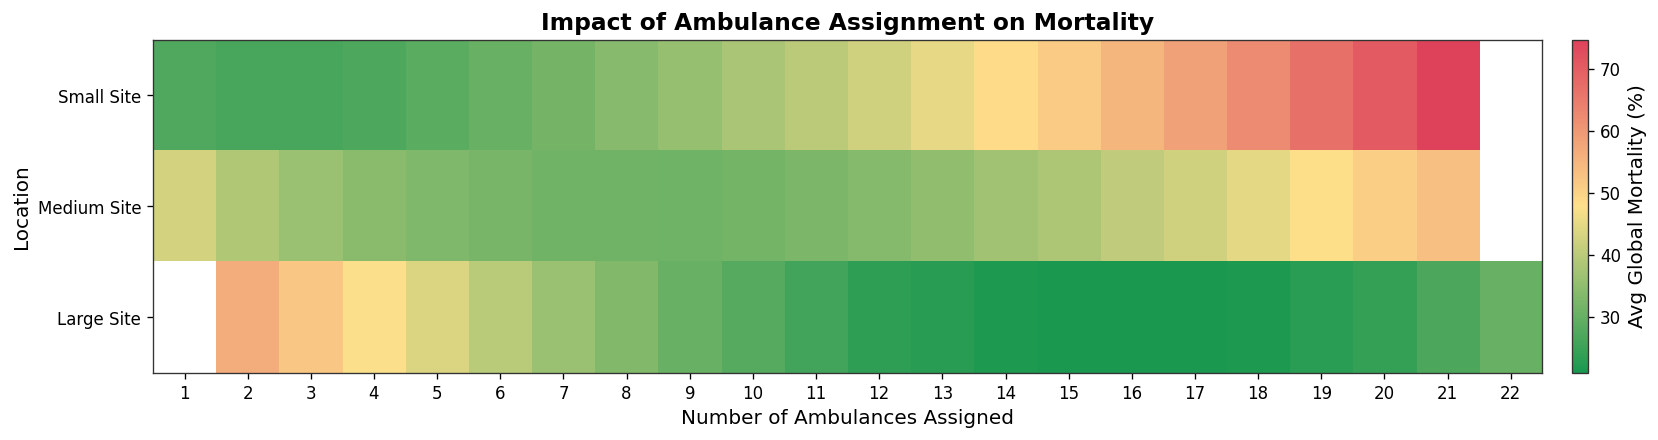

In [ ]:
# Palette
COLOR_MAIN = "#003f5c"
COLOR_ACCENT = "#bc5090"
COLOR_THIRD = "#ffa600"   # highlight
BEST = "#488f31"
WORST = "#ec9f70"

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "grid.color": "#d0d0d0",
    "grid.linestyle": "--",
    "grid.linewidth": 0.8,
})
# PREPARE DATA
if "Mean_Success" in df_results.columns:
    df_results["Mean_Mortality"] = 100 - df_results["Mean_Success"]
else:
    raise ValueError("Missing column: Mean_Success")

max_amb = 22
sites = ["Small", "Medium", "Large"]
site_names = {"Small": "Small Site", "Medium": "Medium Site", "Large": "Large Site"}

# Build aggregated table: rows=sites, cols=ambulance count
cols = np.arange(1, max_amb + 1)
df_agg = pd.DataFrame(index=[site_names[s] for s in sites], columns=cols, dtype=float)

for c in cols:
    for s in sites:
        mask = df_results[s] == c
        if mask.any():
            df_agg.loc[site_names[s], c] = df_results.loc[mask, "Mean_Mortality"].mean()


cmap_mortality = LinearSegmentedColormap.from_list(
    "mortality_good_bad",
    ["#1a9850", "#fee08b", "#de425b"],  # green → yellow → red
    N=256
)

fig, ax = plt.subplots(figsize=(14, 3.8))

im = ax.imshow(
    df_agg.to_numpy(),
    aspect="auto",
    cmap=cmap_mortality,
    interpolation="nearest"
)

# Axes ticks
ax.set_xticks(np.arange(len(cols)))
ax.set_xticklabels(cols)
ax.set_yticks(np.arange(df_agg.shape[0]))
ax.set_yticklabels(df_agg.index)

ax.set_xlabel("Number of Ambulances Assigned")
ax.set_ylabel("Location")
ax.set_title("Impact of Ambulance Assignment on Mortality")

# Colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Avg Global Mortality (%)")

# Annotate values
ANNOTATE = False
if ANNOTATE:
    Z = df_agg.to_numpy()
    for i in range(Z.shape[0]):
        for j in range(Z.shape[1]):
            if np.isfinite(Z[i, j]):
                ax.text(j, i, f"{Z[i,j]:.1f}", ha="center", va="center", fontsize=8, color="#111111")

ax.set_axisbelow(True)
ax.grid(False)

plt.tight_layout()
plt.show()


The visualization highlights a critical disparity in resource sensitivity. The 'Small Site' row remains relatively green even at low allocation numbers (2-4 ambulances), indicating it is robust and does not require heavy resources to maintain system stability. In contrast, the 'Large Site' row shows a dramatic gradient: it is deep red (high mortality) at low allocations and only transitions to green when assigned 14+ ambulances. This confirms that the Large site is the system's "bottleneck" and must be prioritized to prevent global failure.

---
#### Resource Saturation Analysis: Average Patient Wait Time vs. Fleet Allocation
This line graph illustrates the relationship between the number of ambulances assigned to a specific site (x-axis) and the average waiting time for patients at that site (y-axis). Each line represents the efficiency curve for a different incident site. The steepness of the curve indicates how responsive the site's performance is to additional resources.

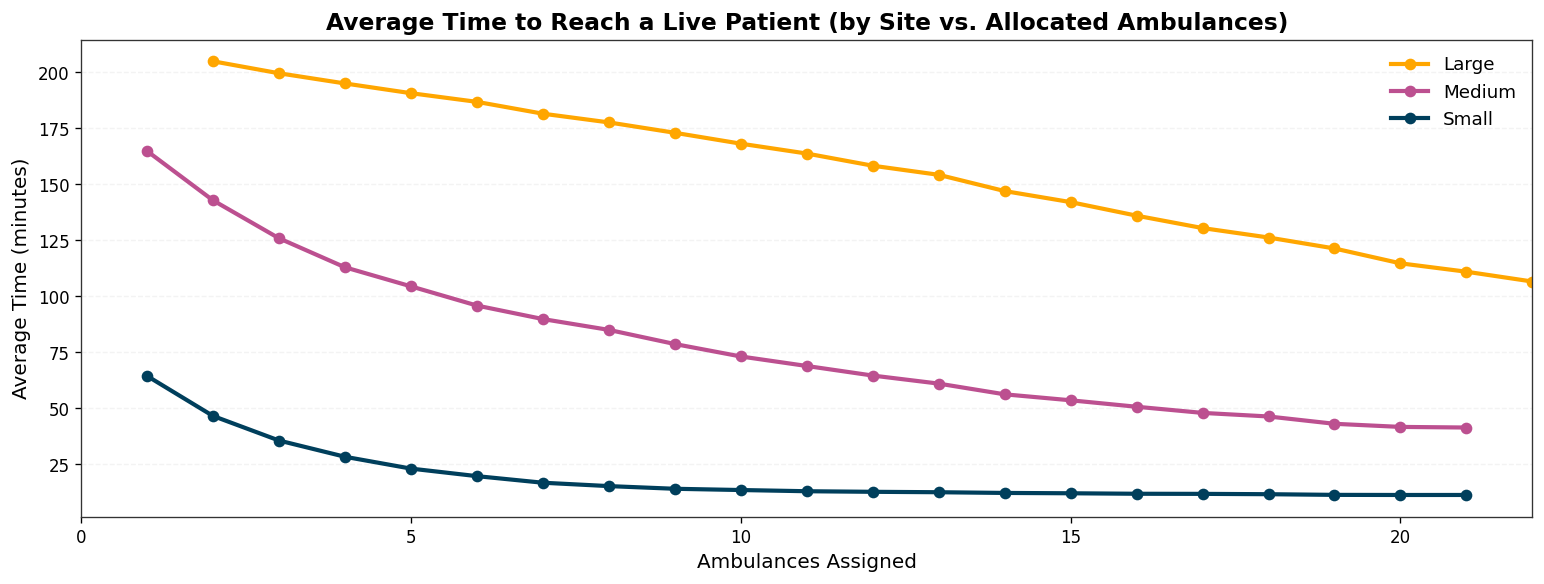

In [ ]:
plt.figure(figsize=(13, 5))

series = [
    ("Large",  "MeanWait_Large",  "#ffa600"),
    ("Medium", "MeanWait_Medium", "#bc5090"),
    ("Small",  "MeanWait_Small",  "#003f5c")
]

for xcol, ycol, color in series:
    grp = df_results.groupby(xcol)[ycol].mean().reset_index().sort_values(xcol)
    plt.plot(grp[xcol], grp[ycol], marker="o", linewidth=2.5, color=color, label=xcol)

plt.title("Average Time to Reach a Live Patient (by Site vs. Allocated Ambulances)", fontweight="bold")
plt.xlabel("Ambulances Assigned")
plt.ylabel("Average Time (minutes)")
plt.grid(axis="y", alpha=0.25)
plt.gca().set_axisbelow(True)
plt.xlim(1, 22)
plt.xticks(np.arange(0, 25, 5))
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


The graph reveals distinct "saturation points" for each site. The 'Small Site' curve (blue) flattens out almost immediately after 3-4 ambulances, meaning adding more resources yields negligible reduction in wait times. In contrast, the 'Large Site' curve (orange) remains steep for much longer, indicating that significant wait-time reductions are still gained even when increasing the fleet from 10 to 15 ambulances. This confirms that the Large site has a much higher capacity for resource utilization before reaching saturation.

---
#### Speed Rate vs. Average Wait Time
**Speed vs. Survival:** This scatter plot visualizes the relationship between the global Mean Wait Time for evacuation and the global Survival Rate for every simulation run. We expect to see a negative correlation: as the average waiting time increases, the survival rate should decrease, confirming that delays directly lead to patient fatalities.

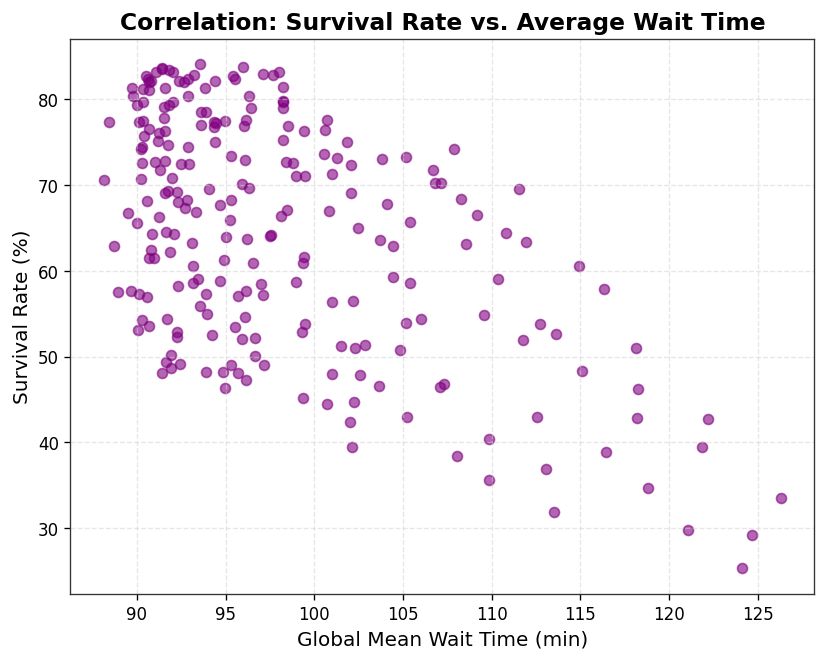

In [ ]:
#Restore the calculation (calculates Global Mean from the 3 sites)
df_results['MeanWait_All'] = df_results[['MeanWait_Small', 'MeanWait_Medium', 'MeanWait_Large']].mean(axis=1)

plt.figure(figsize=(8, 6))
plt.scatter(df_results['MeanWait_All'], df_results['Mean_Success'], alpha=0.6, c='purple')
plt.title('Correlation: Survival Rate vs. Average Wait Time')
plt.xlabel('Global Mean Wait Time (min)')
plt.ylabel('Survival Rate (%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

The graph confirms our model's validity with a clear downward trend: minimizing wait time is the primary driver of success.
- The points in the top-left corner represent the optimal strategies, which minimize wait times to ~35 minutes and achieve the highest survival rates ~70%.
- The vertical spread shows that even with identical wait times, outcomes vary slightly based on luck (e.g., whether "Severe" patients are picked up first).

---
#### System Robustness: 95th Percentile of Patient Waiting Times
This bar chart analyzes the "worst-case" performance for patients by comparing the 95th percentile of waiting times across three strategies: the Optimal allocation found by the simulation, a naive Equal allocation (8 ambulances per site), and the Worst allocation. The 95th percentile indicates the time by which 95% of all patients have been evacuated; a lower value implies a more robust system where fewer patients are left behind for extended periods of time.

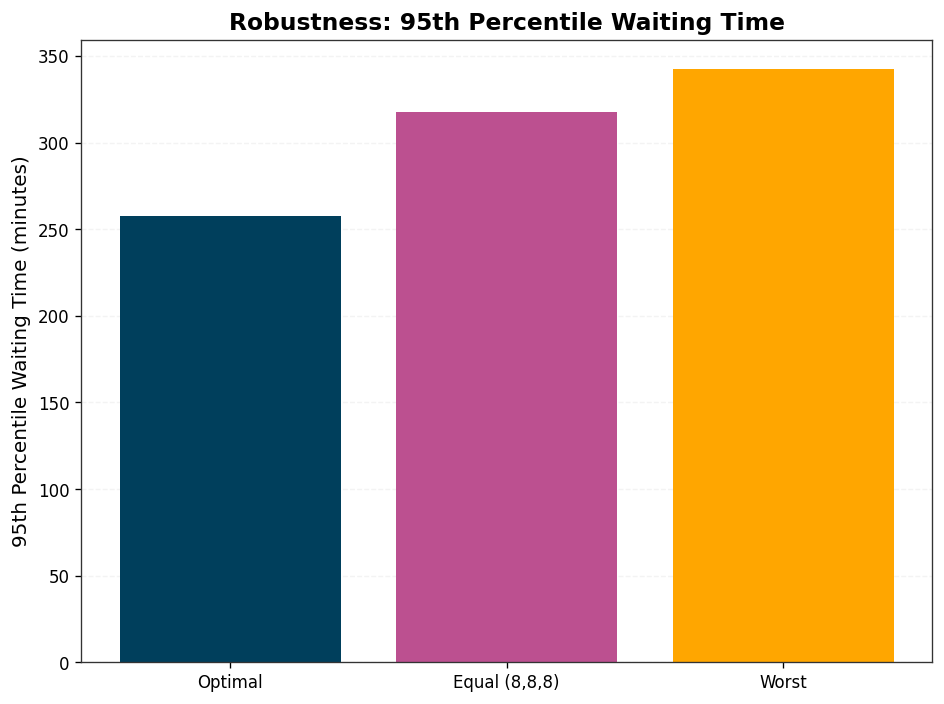

In [ ]:
best = df_results.loc[df_results["Mean_Success"].idxmax()]
worst = df_results.loc[df_results["Mean_Success"].idxmin()]
equal = df_results[(df_results["Small"]==8)&(df_results["Medium"]==8)&(df_results["Large"]==8)].iloc[0]

labels = ["Optimal", "Equal (8,8,8)", "Worst"]
vals = [best["P95Wait_All"], equal["P95Wait_All"], worst["P95Wait_All"]]

plt.figure(figsize=(8,6))
plt.bar(labels, vals, color=["#003f5c","#bc5090","#ffa600"])
plt.ylabel("95th Percentile Waiting Time (minutes)")
plt.title("Robustness: 95th Percentile Waiting Time", fontweight="bold")
plt.grid(axis="y", alpha=0.25)
plt.gca().set_axisbelow(True)
plt.tight_layout()
plt.show()

This comparison highlights that the intuitive approach of equal resource distribution (8-8-8) leads to suboptimal performance because it ignores the asymmetric demand across sites. The optimized model significantly outperforms this naive baseline, proving that data-driven allocation is essential to prevent excessive wait times for the last 5% of patients.
This proves that the Optimal strategy is not just "faster on average," but drastically safer for the patients at the back of the queue.

---
## Sensitivity Analysis


#### Sensitivity to Traffic (Travel Time):
"Will the optimal allocation we found remain as effective even if the traffic conditions will change?"

Running sensitivity for allocation: {'Small': 2, 'Medium': 7, 'Large': 15}
STARTING SENSITIVITY ANALYSIS (on Travel Time)
Traffic Factor x0.8: Mean Success Rate = 91.37%
Traffic Factor x1.0: Mean Success Rate = 84.73%
Traffic Factor x1.2: Mean Success Rate = 78.24%
Traffic Factor x1.5: Mean Success Rate = 67.03%
Traffic Factor x1.8: Mean Success Rate = 58.40%
Traffic Factor x2.0: Mean Success Rate = 53.88%


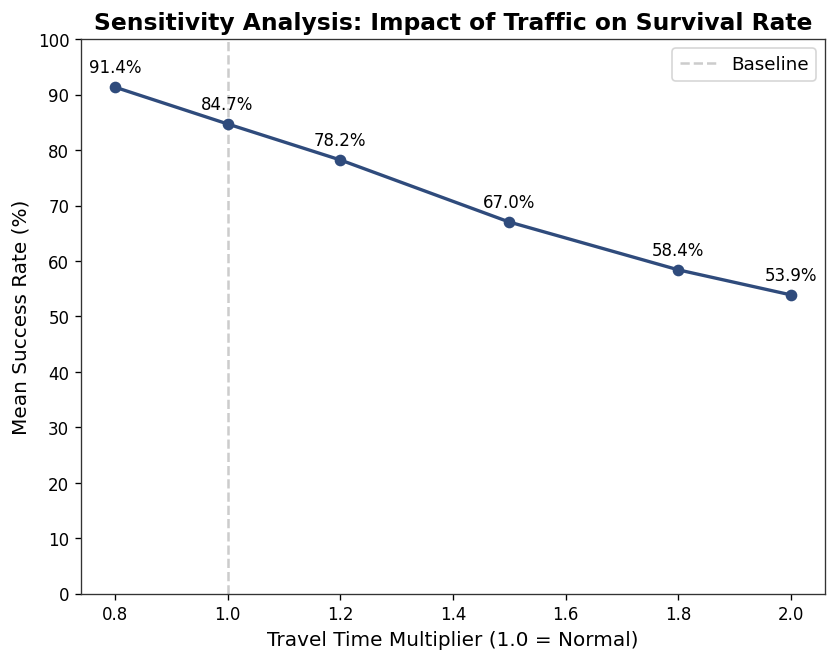

In [ ]:
import copy

def run_sensitivity_traffic(best_allocation, multipliers=[0.8, 1.0, 1.2, 1.5, 1.8, 2.0], n_reps=30):
    """
    Performs sensitivity analysis by multiplying travel times (dist) by a specific factor.

    Parameters:
    - best_allocation: Dictionary with the optimal allocation found (e.g., {'Small': 5, ...})
    - multipliers: List of multipliers to test (1.0 = Normal, 1.5 = 50% more travel time)
    - n_reps: Number of replications per multiplier to ensure statistical stability
    """

    # 1. Backup original site data (to avoid permanent modification)
    original_sites = copy.deepcopy(SITES)

    results_sensitivity = []

    print(f"STARTING SENSITIVITY ANALYSIS (on Travel Time)")

    for mult in multipliers:
        # 2. Temporarily modify travel times in the global SITES variable
        for site in SITES:
            SITES[site]['dist'] = original_sites[site]['dist'] * mult

        # 3. Run simulation multiple times (Replications) to get a stable average
        reps_success = []
        for i in range(n_reps):
            # Use a different seed for each run to ensure variance
            current_seed = i * 100 + int(mult * 10)
            summary, _ = run_one_rep(best_allocation, seed=current_seed)
            reps_success.append(summary['SuccessRate'])

        # Calculate mean success for the current multiplier
        mean_success = np.mean(reps_success)
        results_sensitivity.append({
            'Multiplier': mult,
            'Mean_Success': mean_success
        })

        print(f"Traffic Factor x{mult}: Mean Success Rate = {mean_success:.2f}%")

    # 4. Restore original data to SITES
    for site in SITES:
        SITES[site]['dist'] = original_sites[site]['dist']

    # 5. Plot the results
    df_sens = pd.DataFrame(results_sensitivity)

    plt.figure(figsize=(8, 6))
    plt.plot(df_sens['Multiplier'], df_sens['Mean_Success'], marker='o', linestyle='-', color='#2f4b7c', linewidth=2)
    plt.title('Sensitivity Analysis: Impact of Traffic on Survival Rate', fontsize=14)
    plt.xlabel('Travel Time Multiplier (1.0 = Normal)', fontsize=12)
    plt.ylabel('Mean Success Rate (%)', fontsize=12)
    plt.ylim(0, 100)
    plt.yticks(np.arange(0, 101, 10))

    for x, y in zip(df_sens['Multiplier'], df_sens['Mean_Success']):
        plt.text(
            x,
            y + 2,
            f"{y:.1f}%",
            ha='center',
            va='bottom',
            fontsize=10
        )

    plt.axvline(x=1.0,
                color='gray',
                linestyle='--',
                alpha = 0.4,
                zorder = 0,
                label='Baseline') # Mark the baseline scenario
    plt.legend()
    plt.grid(True, alpha=0.)
    plt.show()

    return df_sens

optimal_allocation = {
    'Small': int(best_row['Small']),
    'Medium': int(best_row['Medium']),
    'Large': int(best_row['Large'])
}

print(f"Running sensitivity for allocation: {optimal_allocation}")
df_sensitivity_results = run_sensitivity_traffic(optimal_allocation)

#### Conclusion
The analysis reveals a quite strong negative correlation between travel times and the survival rate, identifying "cycle time" as a critical system bottleneck. The system is highly sensitive to traffic delays and as expected, time is the critical factor, it's not just about how many ambulances we have, it's about how fast they move.:
- **Optimal conditions (0.8x):** With redcued traffic, the system peaks at 91.37%.
- **Moderate Delays (1.5x):** A 50% increase in travel time causes a sharp decline to 67.03% (a drop of ~17.7%).
- **Severe Delays (2.0x):** Doubling the travel time collapses the system's performance to 53.88%, meaning nearly half of the patients are lost.

Since the "Time to Death" (TTD) for severe patients is short, even minor delays drastically reduce the effectiveness of the optimal ambulance allocation. The steep decline in performance emphasizes that resource allocation alone is not enough and justifies the use of operational priority (e.g., using sirens to bypass traffic), which was found to be essential to maintain the round-trip time within the critical survival window. Without it, even an optimal number of ambulances cannot prevent high mortality rates.

---
#### Sensitivity to Resources (Ambulance Count):
"Given $x$ ambulances, what would be the survival rate in the optimal allocation for that quantity?"

In [ ]:
# 1. Helper to generate combinations summing to N
def generate_allocations(total_amb, min_per_site=1):
    """
    Generates all valid combinations of (Small, Medium, Large)
    that sum exactly to 'total_amb'.
    """
    allocations = []
    # Iterate through all possibilities (enforcing a strict minimum of 0 ambulances)
    for s in range(min_per_site, total_amb - 2*min_per_site + 1):
        for m in range(min_per_site, total_amb - s - min_per_site + 1):
            l = total_amb - s - m
            allocations.append({'Small': s, 'Medium': m, 'Large': l})
    return allocations

# 2. Redefine the Exhaustive Experiment to be Dynamic
def run_experiment_exhaustive():
    """
    Runs the simulation for ALL valid allocations of the CURRENT global NUM_AMBULANCES.
    """
    # STEP A: Generate allocations for the CURRENT fleet size
    current_allocations = generate_allocations(NUM_AMBULANCES)

    results = []

    # STEP B: Loop through these specific allocations
    for i, alloc in enumerate(current_allocations):

        # Run replications (e.g., 5 or 10 reps for speed during sensitivity analysis)
        reps = []
        for r in range(10): # Using 10 reps to keep it fast
            summary, _ = run_one_rep(alloc, seed=RANDOM_SEED + r + (i*100))
            reps.append(summary['SuccessRate'])

        mean_success = np.mean(reps)

        results.append({
            'Small': alloc['Small'],
            'Medium': alloc['Medium'],
            'Large': alloc['Large'],
            'Mean_Success': mean_success
        })

    return pd.DataFrame(results)

In [ ]:
# =================================
# RE-RUNNING THE SENSITIVITY SWEEP
# =================================

ambulance_counts = range(10, 31, 2)
sweep_results = []
original_num = 24 # Store original

#Print the header line without a newline (end="")
print(f"Running Fleet Size Sweep ({min(ambulance_counts)} to {max(ambulance_counts)}): ", end="")

for count in ambulance_counts:
    # 1. Update Global
    NUM_AMBULANCES = count

    # 2. Run Experiment (Now uses the NEW generate_allocations inside)
    df_sweep = run_experiment_exhaustive()

    # 3. Record Best
    best_row = df_sweep.loc[df_sweep['Mean_Success'].idxmax()]

    sweep_results.append({
        "Fleet_Size": count,
        "Max_Success_Rate": best_row['Mean_Success'],
        "Best_Strategy": f"{int(best_row['Small'])}-{int(best_row['Medium'])}-{int(best_row['Large'])}"
    })

    print(".", end="", flush=True) #Print a dot

# Restore Global
NUM_AMBULANCES = original_num
print(" Done!")

# Display Results
df_res = pd.DataFrame(sweep_results)
print("\nCorrected Results:")
print(df_res)

Running Fleet Size Sweep (10 to 30): ........... Done!

Corrected Results:
    Fleet_Size  Max_Success_Rate Best_Strategy
0           10         48.138890         1-2-7
1           12         56.405615         1-2-9
2           14         62.519939        1-3-10
3           16         68.398783        1-5-10
4           18         73.333710        1-5-12
5           20         77.771201        1-5-14
6           22         82.337297        3-6-13
7           24         85.104196        1-8-15
8           26         88.412320        3-9-14
9           28         91.034076        2-9-17
10          30         92.868561        3-9-18


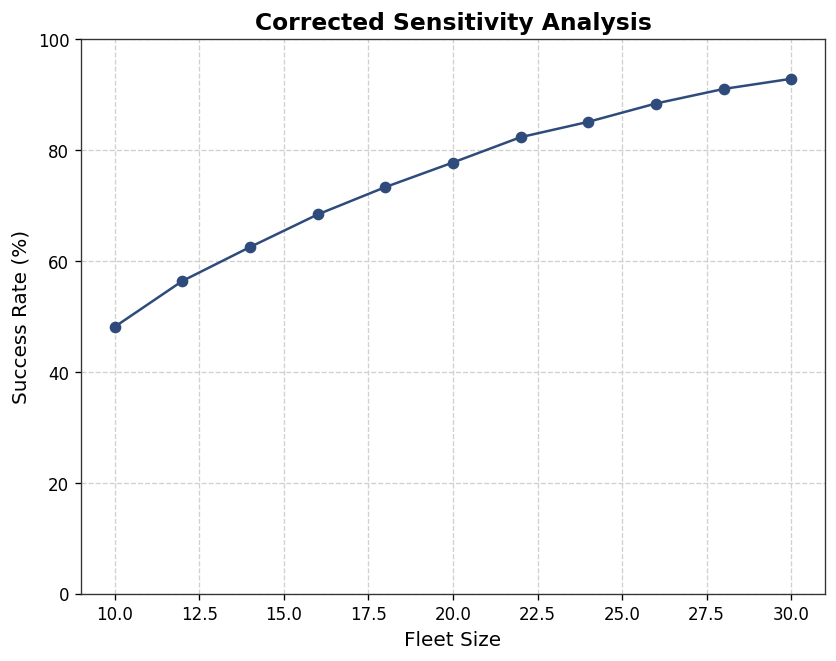

In [ ]:
# Plot
plt.figure(figsize=(8, 6))
plt.plot(df_res['Fleet_Size'], df_res['Max_Success_Rate'], marker='o', linestyle='-', color='#2f4b7c')
plt.title('Corrected Sensitivity Analysis')
plt.xlabel('Fleet Size')
plt.ylabel('Success Rate (%)')
plt.ylim(0, 100)
plt.grid(True)
plt.show()

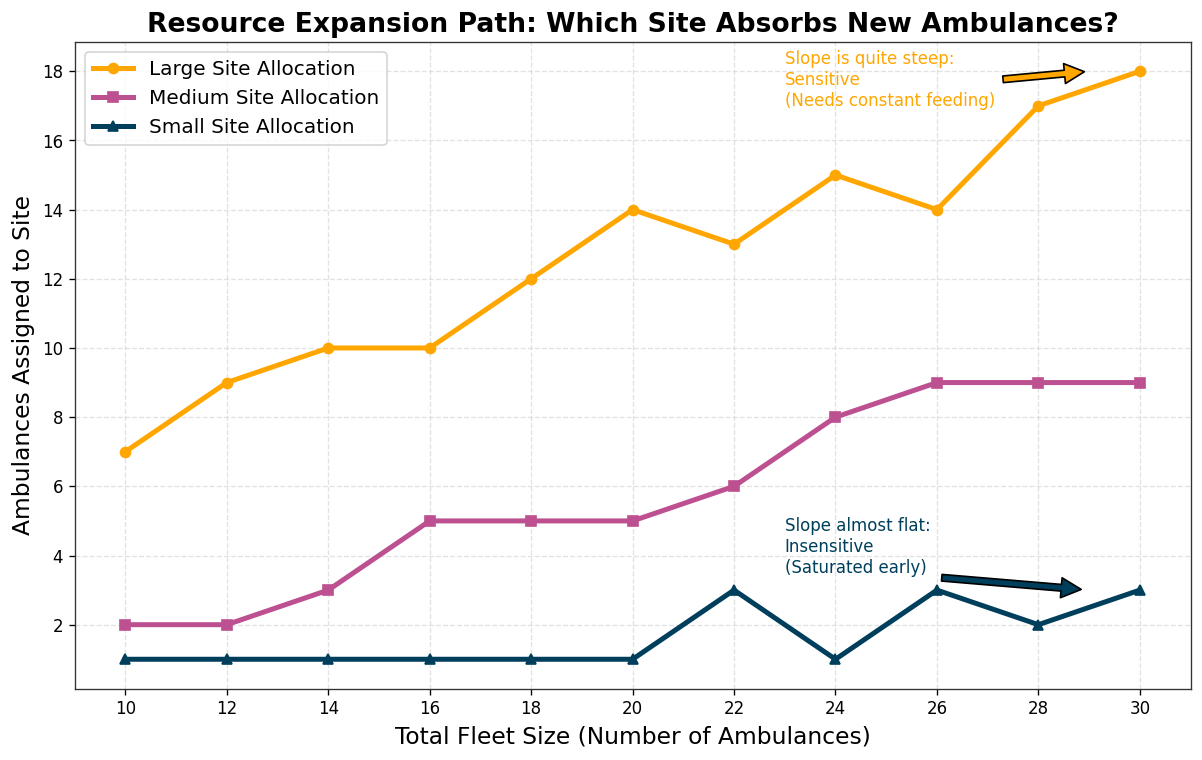

In [ ]:
# ======================================
# VISUALIZING SITE-SPECIFIC SENSITIVITY
# ======================================

try:
    # Split the string 'X-Y-Z' into three columns
    site_allocs = df_res['Best_Strategy'].str.split('-', expand=True).astype(int)
    df_res['Alloc_Small'] = site_allocs[0]
    df_res['Alloc_Medium'] = site_allocs[1]
    df_res['Alloc_Large'] = site_allocs[2]
except Exception as e:
    print(f"Error parsing data: {e}. Make sure you ran the sweep code above first!")

# 2. Plot the "Expansion Path"
plt.figure(figsize=(12, 7))

# Plot 3 Lines
plt.plot(df_res['Fleet_Size'], df_res['Alloc_Large'], marker='o', linewidth=3, color='#ffa600', label='Large Site Allocation')
plt.plot(df_res['Fleet_Size'], df_res['Alloc_Medium'], marker='s', linewidth=3, color='#bc5090', label='Medium Site Allocation')
plt.plot(df_res['Fleet_Size'], df_res['Alloc_Small'], marker='^', linewidth=3, color='#003f5c', label='Small Site Allocation')

# Formatting
plt.title('Resource Expansion Path: Which Site Absorbs New Ambulances?', fontsize=16)
plt.xlabel('Total Fleet Size (Number of Ambulances)', fontsize=14)
plt.ylabel('Ambulances Assigned to Site', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(df_res['Fleet_Size']) # Ensure we see every step (10, 12, 14...)

# Add "Slope Interpretation" Text
plt.annotate('Slope is quite steep:\nSensitive\n(Needs constant feeding)',
             xy=(29, df_res['Alloc_Large'].iloc[-1]),
             xytext=(23, df_res['Alloc_Large'].iloc[-1]-1),
             arrowprops=dict(facecolor='#ffa600', shrink=0.05), fontsize=10, color='#ffa600')

plt.annotate('Slope almost flat:\nInsensitive\n(Saturated early)',
             xy=(29, df_res['Alloc_Small'].iloc[-1]),
             xytext=(23, df_res['Alloc_Small'].iloc[-1]+0.5),
             arrowprops=dict(facecolor='#003f5c', shrink=0.05), fontsize=10, color='#003f5c')

plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(integer=True)) # Force integer ticks
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

#### Sensitivity to Resources: Conclusion
The analysis reveals distinct allocation elasticity for each site:
- **Small Site (Inelastic):** Remarkably insensitive to fleet size. The optimal allocation stays nearly constant (1-3 ambulances) as the fleet triples from 10 to 30. This confirms that due to its short travel time (15 mins), the Small Site requires minimal dedicated resources, allowing the bulk of the fleet to focus on the distant Large Site.
- **Large Site (Highly Elastic):** Absorbs the vast majority of any new resources added to the system. The steep slope of the orange line indicates that the Large Site is the system's "resource sink", meaning it is always hungry for more ambulances to combat the long travel times.

##### Strategic Implication
If the organization acquires new budget for more ambulances, they should almost exclusively be deployed to the Large Site. Adding them to the Small Site yields diminishing returns.